# AntsPy Test

Check this document https://app.readthedocs.org/projects/antspy/downloads/pdf/latest/#page=48.08

In [1]:
import ants
import numpy as np
import matplotlib.pyplot as plt

In [5]:
fixed4d  = ants.image_read("../data/temporal_registered/001_20240313_3T/input_mag_raw.nii.gz",  dimension=4, reorient=False)
moving4d = ants.image_read("../data/temporal_registered/001_20240313_7T/input_mag_raw.nii.gz", dimension=4, reorient=False)

# fixed4d = ants.image_read("../data/nifti_patients/001_20240313_7T/Magnitude_NoProto_WIP_fl3d1r3.nii.gz", dimension=4, reorient=False)
# moving4d = ants.image_read("../data/nifti_patients/001_20240313_3T/Magnitude_NoProto_WIP_pc3d1r3.nii.gz", dimension=4, reorient=False)



print(f"fixed4d:  spacing={fixed4d.spacing}, origin={fixed4d.origin}, direction=\n{fixed4d.direction}")
print(f"moving4d: spacing={moving4d.spacing}, origin={moving4d.origin}, direction=\n{moving4d.direction}")

print(f"fixed4d shape:  {fixed4d.shape}")
print(f"moving4d shape: {moving4d.shape}")

F = fixed4d.numpy()[..., 0]
M = moving4d.numpy()[..., 0]

print(f"fixed0 shape:  {F.shape}")
print(f"moving0 shape: {M.shape}")

fixed0 = ants.from_numpy(F, spacing=fixed4d.spacing[:3], origin=fixed4d.origin[:3], direction=fixed4d.direction[:3,:3])
moving0 = ants.from_numpy(M, spacing=moving4d.spacing[:3], origin=moving4d.origin[:3], direction=moving4d.direction[:3,:3])

reg = ants.registration(
    fixed=fixed0,
    moving=moving0,
    type_of_transform="antsRegistrationSyN[a]",  # rigid + affine  (https://antspyx.readthedocs.io/en/latest/api/ants.registration.html)
    # type_of_transform="SyNRA", # rigid + affine + deformable
    # type_of_transform="TRSAA",  # rigid + affine + deformable + time-varying velocity field
    # type_of_transform="SyN",  # deformable only
    # type_of_transform="SyNCC",  # deformable only with cross-correlation metric
    mask_all_stages=False,
    verbose=True,
)

txlist = reg["fwdtransforms"]  # moving -> fixed

fixed4d:  spacing=(0.5, 0.5, 0.5, 1.0), origin=(114.48587799072266, 87.89588165283203, -31.12738037109375, 0.0), direction=
[[-0.99723422 -0.04528414 -0.05893437  0.        ]
 [ 0.03710887 -0.99040899  0.13309008  0.        ]
 [-0.06439599  0.13053499  0.98935018  0.        ]
 [ 0.          0.          0.          1.        ]]
moving4d: spacing=(0.5, 0.5, 0.5, 1.0), origin=(108.12255096435547, 109.4660873413086, -27.934358596801758, 0.0), direction=
[[-0.99940226  0.01186167 -0.03247175  0.        ]
 [-0.01270033 -0.99958789  0.02574397  0.        ]
 [-0.032153    0.02614099  0.99914105  0.        ]
 [ 0.          0.          0.          1.        ]]
fixed4d shape:  (448, 448, 48, 9)
moving4d shape: (448, 448, 48, 14)
fixed0 shape:  (448, 448, 48)
moving0 shape: (448, 448, 48)
antsRegistration --dimensionality 3 -r [0x11edd6c68,0x11edd6948,1] --output [/var/folders/b5/0mc1_5sn3fnfc23rbdcrvj140000gn/T/tmpk4u2da00,0x11f6bafc8,0x11edd66e8] --transform Rigid[0.1] --metric MI[0x11edd6c68,0x

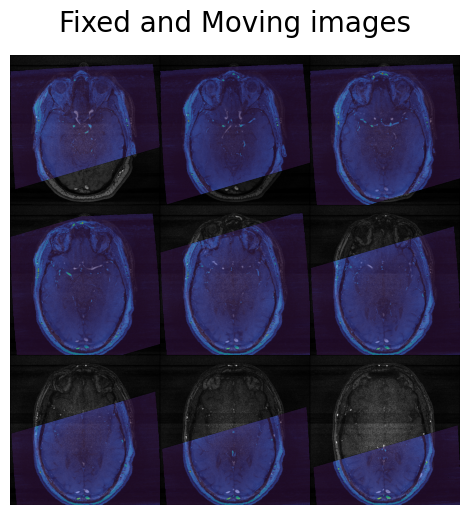

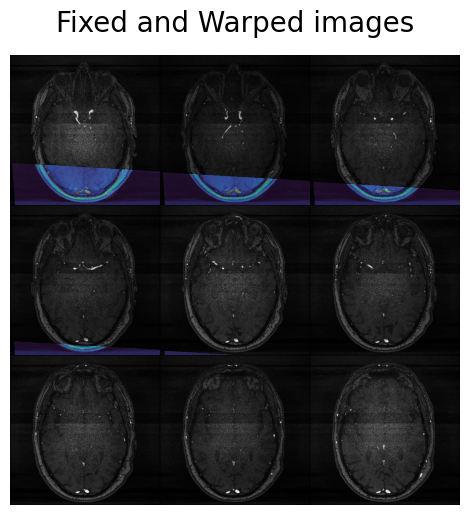

In [6]:
warped0 = ants.apply_transforms(fixed=fixed0, moving=moving0, transformlist=txlist, interpolator="bSpline")

ants.plot(fixed0, overlay=moving0, axis=2, nslices=9, overlay_alpha=0.6, title="Fixed and Moving images")


# Después: warped sobre fixed
ants.plot(fixed0, overlay=reg['warpedmovout'], axis=2, nslices=9, overlay_alpha=0.6, title="Fixed and Warped images")

In [10]:
moving_np = moving4d.numpy()
T = moving4d.shape[3]

warped_frames = []
for t in range(T):
    mov_t = ants.from_numpy(
        moving_np[..., t],
        spacing=moving4d.spacing[:3],
        origin=moving4d.origin[:3],
        direction=moving4d.direction[:3,:3]
    )
    mov_t_w = ants.apply_transforms(
        fixed=fixed0,
        moving=mov_t,
        transformlist=txlist,
        interpolator="bSpline"
    )
    warped_frames.append(mov_t_w)


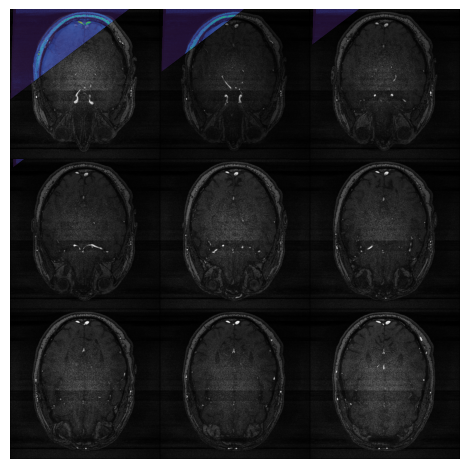

In [11]:
ants.plot(fixed0, overlay=warped_frames[0], axis=2, nslices=9, overlay_alpha=0.6)

In [ ]:
# stacked: (x,y,z,T)
warped_np = np.stack([im.numpy() for im in warped_frames], axis=-1)

# usa geometría 4D del fixed4d (incluye 4th origin/spacing/direction)
# si quieres forzar dt=1.0:
spacing4 = list(fixed4d.spacing)
spacing4[3] = 1.0

warped4d = ants.from_numpy(
    warped_np,
    origin=fixed4d.origin,
    spacing=tuple(spacing4),
    direction=fixed4d.direction
)

ants.image_write(warped4d, "../data/registered_patients/mag_7T_in_3T_4d.nii.gz")

In [14]:
print("fixed0:",  fixed0.spacing,  fixed0.origin,  fixed0.direction)
print("moving0:", moving0.spacing, moving0.origin, moving0.direction)
print("warped0:", warped0.spacing, warped0.origin, warped0.direction)

fixed0: (0.5, 0.5, 0.5) (113.27775573730469, 90.624267578125, -10.845730781555176) [[-0.99723421 -0.04528411 -0.05893448]
 [ 0.03710882 -0.99040896  0.13309033]
 [-0.06439611  0.13053523  0.98935014]]
moving0: (0.5, 0.4999999701976776, 0.5000002384185791) (108.12259674072266, 109.46617126464844, -27.934377670288086) [[-0.99940225  0.01186172 -0.0324721 ]
 [-0.0127004  -0.99958788  0.0257444 ]
 [-0.03215335  0.02614142  0.99914103]]
warped0: (0.5, 0.5, 0.5) (113.27775573730469, 90.624267578125, -10.845730781555176) [[-0.99723421 -0.04528411 -0.05893448]
 [ 0.03710882 -0.99040896  0.13309033]
 [-0.06439611  0.13053523  0.98935014]]


## ANTsPy Registration Pipeline (N4 + Auto Mask + TRSAA/SyNRA) for 4D MAG (Register t=0, Apply to all t)

In [7]:
import ants
import numpy as np
import matplotlib.pyplot as plt

In [8]:
fixed4d  = ants.image_read("../data/temporal_registered/001_20240313_3T/input_mag_raw.nii.gz",  dimension=4, reorient=False)
moving4d = ants.image_read("../data/temporal_registered/001_20240313_7T/input_mag_raw.nii.gz", dimension=4, reorient=False)

# fixed4d = ants.image_read("../data/nifti_patients/001_20240313_7T/Magnitude_NoProto_WIP_fl3d1r3.nii.gz", dimension=4, reorient=False)
# moving4d = ants.image_read("../data/nifti_patients/001_20240313_3T/Magnitude_NoProto_WIP_pc3d1r3.nii.gz", dimension=4, reorient=False)



print(f"fixed4d:  spacing={fixed4d.spacing}, origin={fixed4d.origin}, direction=\n{fixed4d.direction}")
print(f"moving4d: spacing={moving4d.spacing}, origin={moving4d.origin}, direction=\n{moving4d.direction}")

print(f"fixed4d shape:  {fixed4d.shape}")
print(f"moving4d shape: {moving4d.shape}")

F = fixed4d.numpy()[..., 0]
M = moving4d.numpy()[..., 0]

print(f"fixed0 shape:  {F.shape}")
print(f"moving0 shape: {M.shape}")

fixed0 = ants.from_numpy(F, spacing=fixed4d.spacing[:3], origin=fixed4d.origin[:3], direction=fixed4d.direction[:3,:3])
moving0 = ants.from_numpy(M, spacing=moving4d.spacing[:3], origin=moving4d.origin[:3], direction=moving4d.direction[:3,:3])

fixed4d:  spacing=(0.5, 0.5, 0.5, 1.0), origin=(114.48587799072266, 87.89588165283203, -31.12738037109375, 0.0), direction=
[[-0.99723422 -0.04528414 -0.05893437  0.        ]
 [ 0.03710887 -0.99040899  0.13309008  0.        ]
 [-0.06439599  0.13053499  0.98935018  0.        ]
 [ 0.          0.          0.          1.        ]]
moving4d: spacing=(0.5, 0.5, 0.5, 1.0), origin=(108.12255096435547, 109.4660873413086, -27.934358596801758, 0.0), direction=
[[-0.99940226  0.01186167 -0.03247175  0.        ]
 [-0.01270033 -0.99958789  0.02574397  0.        ]
 [-0.032153    0.02614099  0.99914105  0.        ]
 [ 0.          0.          0.          1.        ]]
fixed4d shape:  (448, 448, 48, 9)
moving4d shape: (448, 448, 48, 14)
fixed0 shape:  (448, 448, 48)
moving0 shape: (448, 448, 48)


ANTsPyNet not available -> using ants.get_mask() fallback. No module named 'antspynet'


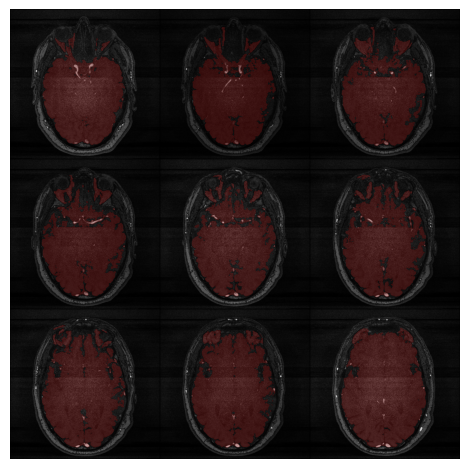

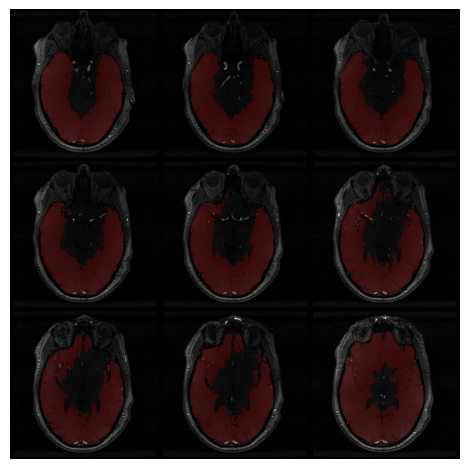

In [9]:
# -----------------------------
# Masking: prefer ANTsPyNet brain extraction; fallback to ants.get_mask
# -----------------------------
use_antspynet = False
try:
    import antspynet
    use_antspynet = True
    print("ANTsPyNet available: using deep-learning brain extraction.")
except Exception as e:
    print("ANTsPyNet not available -> using ants.get_mask() fallback.", str(e))

def brain_mask(img3d: "ants.ANTsImage", cleanup=2) -> "ants.ANTsImage":
    """
    Returns a binary brain mask in the same space as img3d.
    - If ANTsPyNet is available, uses antspynet.brain_extraction (U-Net pretrained).
    - Otherwise uses ants.get_mask + basic morphology cleanup.
    """
    if use_antspynet:
        # Try 't1' first. If it looks wrong, try modality='t2' depending on your MAG contrast.
        prob = antspynet.brain_extraction(img3d, modality="t1")
        m = ants.threshold_image(prob, 0.5, 1.0)  # binarize
        m = ants.iMath(m, "FillHoles")
        m = ants.iMath(m, "GetLargestComponent")
        return m
    else:
        m = ants.get_mask(img3d, cleanup=cleanup)
        # m = ants.threshold_image(ants.otsu_segmentation(img3d, k=2), 1, 1)
        m = ants.iMath(m, "FillHoles")
        m = ants.iMath(m, "GetLargestComponent")
        m = ants.iMath(m, "ME", 1)  # erosion
        m = ants.iMath(m, "MD", 2)  # dilation
        m = ants.iMath(m, "FillHoles")
        return m

# Get brain masks
fixed_mask0  = brain_mask(fixed0, cleanup=1)
moving_mask0 = brain_mask(moving0, cleanup=2)

# Visual check: masks overlaid
ants.plot(fixed0,  overlay=fixed_mask0,  axis=2, nslices=9, overlay_alpha=0.35)
ants.plot(moving0, overlay=moving_mask0, axis=2, nslices=9, overlay_alpha=0.35)


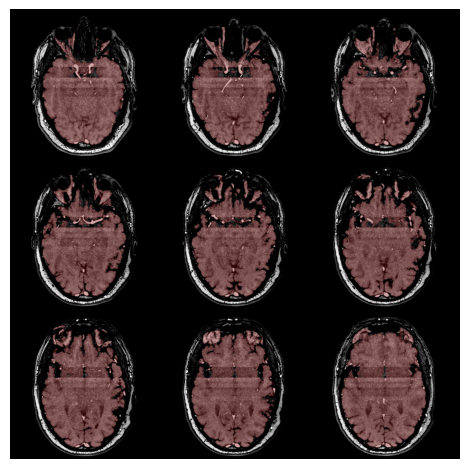

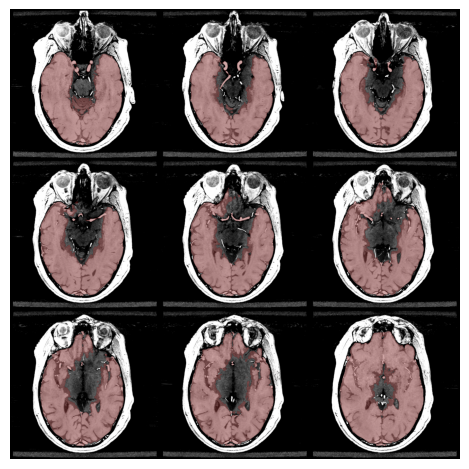

In [10]:
# -----------------------------
# N4 bias field correction (both images, using masks)
# -----------------------------

def winsorize_image(img, p_low=0.01, p_high=0.99, mask=None):
    a = img.numpy()
    if mask is not None:
        m = mask.numpy() > 0
        vals = a[m]
    else:
        vals = a[np.isfinite(a)]

    lo = float(np.quantile(vals, p_low))
    hi = float(np.quantile(vals, p_high))

    a_clip = np.clip(a, lo, hi)

    out = ants.from_numpy(
        a_clip,
        spacing=img.spacing,
        origin=img.origin,
        direction=img.direction
    )
    return out, lo, hi


fixed0_n4 = ants.n4_bias_field_correction(
    fixed0, mask=fixed_mask0, shrink_factor=4, rescale_intensities=True
)
moving0_n4 = ants.n4_bias_field_correction(
    moving0, mask=moving_mask0, shrink_factor=4, rescale_intensities=True
)

# Denoising with Rician noise model
fixed0_dn = ants.denoise_image(fixed0_n4, noise_model="Rician")
moving0_dn = ants.denoise_image(moving0_n4, noise_model="Rician")

fixed0_w,  _, _ = winsorize_image(fixed0_dn,  p_low=0.01, p_high=0.99, mask=fixed_mask0)
moving0_w, _, _ = winsorize_image(moving0_dn, p_low=0.01, p_high=0.99, mask=moving_mask0)

# Optionally regenerate masks after N4 (sometimes improves)
fixed_mask  = brain_mask(fixed0_w, cleanup=1)
moving_mask = brain_mask(moving0_w, cleanup=1)
ants.plot(fixed0_w, overlay=fixed_mask, axis=2, nslices=9, overlay_alpha=0.35)
ants.plot(moving0_w, overlay=moving_mask, axis=2, nslices=9, overlay_alpha=0.35)

Registration type: SyNRA
Forward transforms: ['/var/folders/b5/0mc1_5sn3fnfc23rbdcrvj140000gn/T/tmpelcd3xdc1Warp.nii.gz', '/var/folders/b5/0mc1_5sn3fnfc23rbdcrvj140000gn/T/tmpelcd3xdc0GenericAffine.mat']


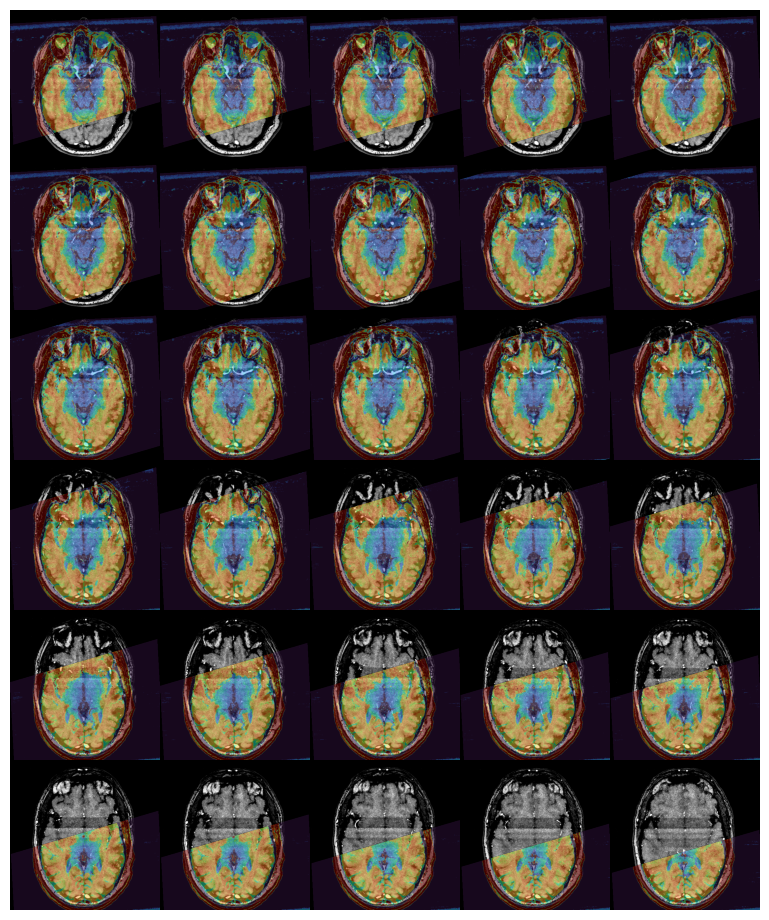

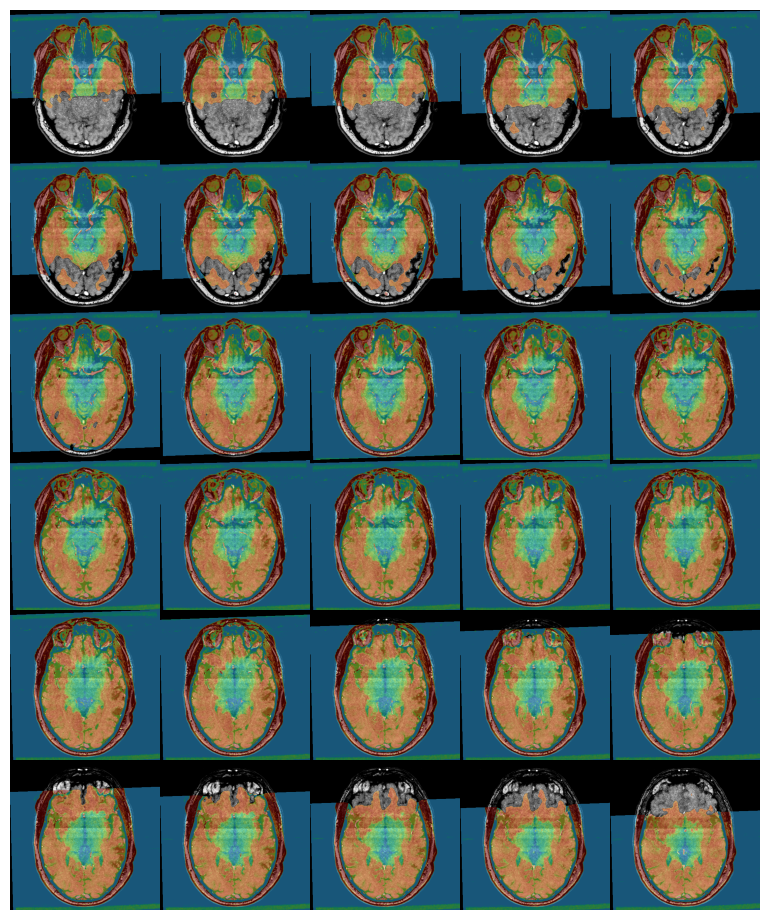

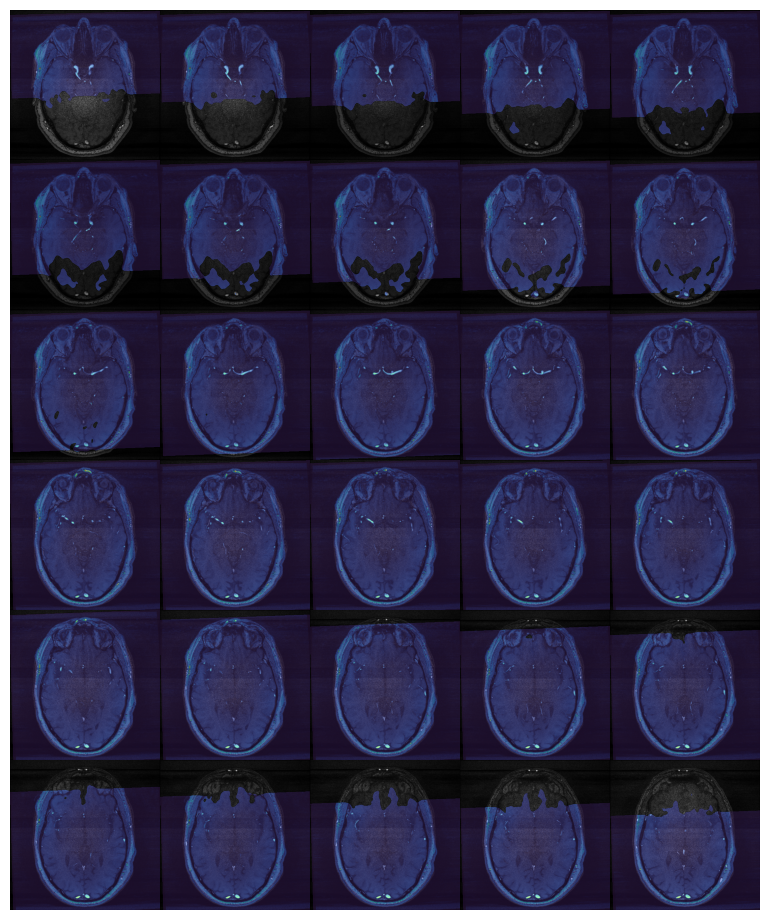

In [14]:
# -----------------------------
# Registration 
# -----------------------------
# TRSAA: strong linear pipeline (often robust for 3T<->7T)
# SyNRA: adds deformable registration 
REG_TYPE = "antsRegistrationSyN[a]"  # change to "SyNRA" if TRSAA is not enough

reg = ants.registration(
    fixed=fixed0_w,
    moving=moving0_w,
    type_of_transform=REG_TYPE,
    mask=fixed_mask,
    moving_mask=moving_mask,
    mask_all_stages=True
)

txlist = reg["fwdtransforms"]      # moving -> fixed space
warped0 = reg["warpedmovout"]      # moving0_n4 warped into fixed0_n4 space

print("Registration type:", REG_TYPE)
print("Forward transforms:", txlist)

# Visual QC: before vs after overlay
ants.plot(fixed0_w, overlay=moving0_w, axis=2, nslices=30, overlay_alpha=0.5)  # BEFORE
ants.plot(fixed0_w, overlay=warped0, axis=2, nslices=30, overlay_alpha=0.5)  # AFTER


#Apply transforms to original moving image (not N4/denoised/winsorized)
warped0_orig = ants.apply_transforms(
    fixed=fixed0,
    moving=moving0,
    transformlist=txlist,
    interpolator="bSpline"
)

ants.plot(fixed0, overlay=warped0_orig, axis=2, nslices=30, overlay_alpha=0.5)  # AFTER

In [12]:
warped0

ANTsImage (LPI)
	 Pixel Type : float (float32)
	 Components : 1
	 Dimensions : (448, 448, 48)
	 Spacing    : (0.5, 0.5, 0.5)
	 Origin     : (113.2778, 90.6243, -10.8457)
	 Direction  : [-0.9972 -0.0453 -0.0589  0.0371 -0.9904  0.1331 -0.0644  0.1305  0.9894]

In [12]:
ants.image_write(warped0, "../data/mag_7T_in_3T_4d.nii.gz")

In [1]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-

import os
import numpy as np
import ants

# -----------------------------
# IO
# -----------------------------
fixed_path  = "../data/temporal_registered/001_20240313_3T/input_mag_raw.nii.gz"
moving_path = "../data/temporal_registered/001_20240313_7T/input_mag_raw.nii.gz"
out_dir     = "../data/interfield_registered/001_20240313_3T_7T"
os.makedirs(out_dir, exist_ok=True)

REG_TYPE = "antsRegistrationSyN[a]"   # robusto (affine+SyN). Alternativas: "TRSAA", "SyNRA"
APPLY_INTERP = "linear"              # para magnitude: linear suele ser mejor que bSpline
QC_AXIS = 2                          # 2=axial si ya estás en RAS
REF_T = 0

# -----------------------------
# Utils
# -----------------------------
def frame3d_from_4d(img4d: "ants.ANTsImage", t: int) -> "ants.ANTsImage":
    arr = img4d.numpy()[..., t]
    return ants.from_numpy(
        arr,
        spacing=img4d.spacing[:3],
        origin=img4d.origin[:3],
        direction=img4d.direction[:3, :3],
    )

def winsorize_image(img, p_low=0.01, p_high=0.99, mask=None):
    a = img.numpy()
    if mask is not None:
        m = mask.numpy() > 0
        vals = a[m]
    else:
        vals = a[np.isfinite(a)]
    lo = float(np.quantile(vals, p_low))
    hi = float(np.quantile(vals, p_high))
    a_clip = np.clip(a, lo, hi)
    return ants.from_numpy(a_clip, spacing=img.spacing, origin=img.origin, direction=img.direction)

# tqdm opcional
try:
    from tqdm import tqdm
except Exception:
    tqdm = None

def progress_iter(it, **kwargs):
    if tqdm is None:
        return it
    return tqdm(it, **kwargs)

# -----------------------------
# Load 4D (NO reorient)
# -----------------------------
fixed4d  = ants.image_read(fixed_path,  dimension=4, reorient=False)
moving4d = ants.image_read(moving_path, dimension=4, reorient=False)

print("Fixed 4D:",  fixed4d.shape,  "spacing:", fixed4d.spacing,  "origin:", fixed4d.origin)
print("Moving 4D:", moving4d.shape, "spacing:", moving4d.spacing, "origin:", moving4d.origin)
print("Fixed dir:\n", fixed4d.direction[:3,:3])
print("Moving dir:\n", moving4d.direction[:3,:3])

# sanity: mismo número de frames?
Tf = fixed4d.shape[3] if len(fixed4d.shape) == 4 else 1
Tm = moving4d.shape[3] if len(moving4d.shape) == 4 else 1
if Tf != Tm:
    print(f"[!] Warning: fixed T={Tf} != moving T={Tm}. Aplicaré transform a los frames disponibles del moving.")

# -----------------------------
# Choose reference frame (t=0)
# -----------------------------
fixed0  = frame3d_from_4d(fixed4d,  REF_T)
moving0 = frame3d_from_4d(moving4d, REF_T)

# -----------------------------
# Brain masking (ANTsPyNet si existe; si no get_mask)
# -----------------------------
use_antspynet = False
try:
    import antspynet
    use_antspynet = True
    print("ANTsPyNet available: brain_extraction().")
except Exception as e:
    print("ANTsPyNet NOT available -> using ants.get_mask().", str(e))

def brain_mask(img3d: "ants.ANTsImage", cleanup=2) -> "ants.ANTsImage":
    if use_antspynet:
        prob = antspynet.brain_extraction(img3d, modality="t1")
        m = ants.threshold_image(prob, 0.5, 1.0)
        m = ants.iMath(m, "FillHoles")
        m = ants.iMath(m, "GetLargestComponent")
        return m
    else:
        m = ants.get_mask(img3d, cleanup=cleanup)
        m = ants.iMath(m, "FillHoles")
        m = ants.iMath(m, "GetLargestComponent")
        # suaviza un poco
        m = ants.iMath(m, "ME", 1)
        m = ants.iMath(m, "MD", 2)
        m = ants.iMath(m, "FillHoles")
        return m

fixed_mask0  = brain_mask(fixed0,  cleanup=1)
moving_mask0 = brain_mask(moving0, cleanup=2)

# -----------------------------
# Preprocess: N4 + denoise + winsorize (solo para estimar transform)
# -----------------------------
fixed0_n4 = ants.n4_bias_field_correction(fixed0,  mask=fixed_mask0,  shrink_factor=4, rescale_intensities=True)
moving0_n4 = ants.n4_bias_field_correction(moving0, mask=moving_mask0, shrink_factor=4, rescale_intensities=True)

fixed0_dn  = ants.denoise_image(fixed0_n4,  noise_model="Rician")
moving0_dn = ants.denoise_image(moving0_n4, noise_model="Rician")

fixed0_w  = winsorize_image(fixed0_dn,  p_low=0.01, p_high=0.99, mask=fixed_mask0)
moving0_w = winsorize_image(moving0_dn, p_low=0.01, p_high=0.99, mask=moving_mask0)

# Regenera máscaras (a veces mejora)
fixed_mask  = brain_mask(fixed0_w,  cleanup=1)
moving_mask = brain_mask(moving0_w, cleanup=1)

# QC masks
ants.plot(fixed0_w,  overlay=fixed_mask,  axis=QC_AXIS, nslices=9, overlay_alpha=0.35, title="Fixed mask")
ants.plot(moving0_w, overlay=moving_mask, axis=QC_AXIS, nslices=9, overlay_alpha=0.35, title="Moving mask")



# -----------------------------
# Registration
# -----------------------------
reg = ants.registration(
    fixed=fixed0_w,
    moving=moving0_w,
    type_of_transform=REG_TYPE,
    initial_transform=None,
    mask=fixed_mask,
    moving_mask=moving_mask,
    mask_all_stages=True,
)

txlist = reg["fwdtransforms"]  # moving -> fixed
warped0 = reg["warpedmovout"]

print("Registration type:", REG_TYPE)
print("Forward transforms:", txlist)

# QC before/after
ants.plot(fixed0_w, overlay=moving0_w, axis=QC_AXIS, nslices=30, overlay_alpha=0.45, title="BEFORE (preproc)")
ants.plot(fixed0_w, overlay=warped0,   axis=QC_AXIS, nslices=30, overlay_alpha=0.45, title="AFTER (preproc)")

# Save transforms
for k, tx in enumerate(txlist):
    # ANTs ya guarda los .mat/.nii.gz donde sea; copiamos a out_dir
    base = os.path.basename(tx)
    dst = os.path.join(out_dir, f"tx_{k:02d}_{base}")
    try:
        import shutil
        shutil.copy(tx, dst)
    except Exception:
        pass

# -----------------------------
# Apply transforms to ORIGINAL 3D frame (t=0) for QC
# -----------------------------
warped0_orig = ants.apply_transforms(
    fixed=fixed0,
    moving=moving0,
    transformlist=txlist,
    interpolator=APPLY_INTERP,
)
ants.plot(fixed0, overlay=warped0_orig, axis=QC_AXIS, nslices=30, overlay_alpha=0.45, title="AFTER (orig t=0)")

# # -----------------------------
# # Apply transforms to FULL 4D moving (frame by frame)
# # -----------------------------
# T_apply = min(Tf, Tm)
# moving_warped_frames = []

# print(f"Applying transforms to moving 4D: {T_apply} frames ...")
# for t in progress_iter(range(T_apply), desc="Warp 4D frames"):
#     mov_t = frame3d_from_4d(moving4d, t)
#     warped_t = ants.apply_transforms(
#         fixed=fixed0,     # define target grid = fixed space
#         moving=mov_t,
#         transformlist=txlist,
#         interpolator=APPLY_INTERP,
#     )
#     moving_warped_frames.append(warped_t.numpy())

# # Stack back to 4D numpy (X,Y,Z,T)
# moving_warped_np = np.stack(moving_warped_frames, axis=3).astype(np.float32)

# # Build output 4D ANTs image in fixed space (keep fixed geometry)
# moving4d_warped = ants.from_numpy(
#     moving_warped_np,
#     spacing=fixed4d.spacing[:3],
#     origin=fixed4d.origin[:3],
#     direction=fixed4d.direction[:3,:3],
# )

# out_nii = os.path.join(out_dir, "moving_in_fixed_space_4d.nii.gz")
# ants.image_write(moving4d_warped, out_nii)
# print("Saved:", out_nii)

# # -----------------------------
# # Quick QC: overlay fixed t=0 vs warped moving t=0
# # -----------------------------
# warped0_chk = frame3d_from_4d(moving4d_warped, 0)
# ants.plot(fixed0, overlay=warped0_chk, axis=QC_AXIS, nslices=30, overlay_alpha=0.45, title="FINAL QC (t=0)")

Fixed 4D: (448, 448, 48, 9) spacing: (0.5, 0.5, 0.5, 1.0) origin: (114.48587799072266, 87.89588165283203, -31.12738037109375, 0.0)
Moving 4D: (448, 448, 48, 14) spacing: (0.5, 0.5, 0.5, 1.0) origin: (108.12255096435547, 109.4660873413086, -27.934358596801758, 0.0)
Fixed dir:
 [[-0.99723422 -0.04528414 -0.05893437]
 [ 0.03710887 -0.99040899  0.13309008]
 [-0.06439599  0.13053499  0.98935018]]
Moving dir:
 [[-0.99940226  0.01186167 -0.03247175]
 [-0.01270033 -0.99958789  0.02574397]
 [-0.032153    0.02614099  0.99914105]]
[!] Warning: fixed T=9 != moving T=14. Aplicaré transform a los frames disponibles del moving.
ANTsPyNet available: brain_extraction().


/Users/alejo/Documents/Internship/4DFlowNet/.venv_antspynet/lib/python3.11/site-packages/keras/src/utils/generic_utils.py:238: RuntimeWarning: divide by zero encountered in log10
  numdigits = int(np.log10(self.target)) + 1


OverflowError: cannot convert float infinity to integer

# Temporal Registration

img4d shape: (448, 448, 48, 9)
img4d spacing: (0.5, 0.5, 0.5, 0.08291999995708466)
img4d origin: (113.27775573730469, 90.624267578125, -10.845730781555176, 0.0)
img4d direction:
 [[-0.99723421 -0.04528411 -0.05893448  0.        ]
 [ 0.03710882 -0.99040896  0.13309033  0.        ]
 [-0.06439611  0.13053523  0.98935014  0.        ]
 [ 0.          0.          0.          1.        ]]


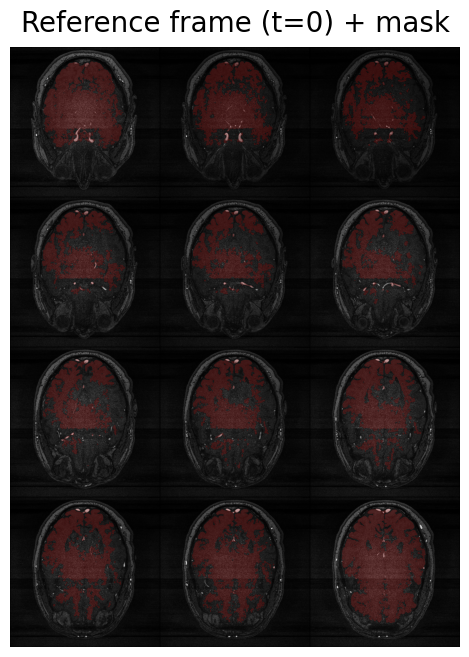

In [ ]:
# Temporal registration (motion correction): register every frame (t) to the first frame (t=0)
# Includes visual QC before/after + simple quantitative QC

import ants
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------
# Load 4D (pick ONE series to test temporal registration)
# ----------------------------
img4d = ants.image_read(
    "../data/nifti_patients/001_20240313_3T/Magnitude_NoProto_WIP_pc3d1r3.nii.gz",
    dimension=4,
    reorient=False
)
# Or try the 7T one:
# img4d = ants.image_read("../data/nifti_patients/001_20240313_7T/Magnitude_NoProto_WIP_fl3d1r3.nii.gz", dimension=4, reorient=False)

print("img4d shape:", img4d.shape)
print("img4d spacing:", img4d.spacing)
print("img4d origin:", img4d.origin)
print("img4d direction:\n", img4d.direction)

T = img4d.shape[3]
img_np = img4d.numpy()

# ----------------------------
# Helpers
# ----------------------------
def frame3d_from_4d(img4d, t):
    """Extract frame t from 4D ANTsImage as 3D ANTsImage preserving geometry."""
    arr = img4d.numpy()[..., t]
    return ants.from_numpy(
        arr,
        spacing=img4d.spacing[:3],
        origin=img4d.origin[:3],
        direction=img4d.direction[:3, :3],
    )

def make_mask_reference(ref3d):
    """
    Simple robust mask for QC + optionally to constrain registration.
    For MAG images, this usually works OK. Replace with your antspynet mask if you want.
    """
    m = ants.get_mask(ref3d, cleanup=2)
    m = ants.iMath(m, "FillHoles")
    m = ants.iMath(m, "GetLargestComponent")
    return m

def mean_abs_diff(a_img, b_img, mask=None):
    a = a_img.numpy()
    b = b_img.numpy()
    if mask is None:
        return float(np.mean(np.abs(a - b)))
    m = mask.numpy() > 0
    return float(np.mean(np.abs(a[m] - b[m])))

def checkerboard(fixed, moving, squares=(8,8,8)):
    """Fast checkerboard-like QC using ants visualization tool."""
    return ants.create_warped_grid(moving, grid_directions=(True, True, True), grid_spacing=10, grid_offset=0)  # optional

# ----------------------------
# Core: register each frame to t=0
# ----------------------------
ref_t = 0
ref = frame3d_from_4d(img4d, ref_t)

# Optional: build one mask from the reference frame (helps stability + QC)
ref_mask = make_mask_reference(ref)
ants.plot(ref, overlay=ref_mask, axis=2, nslices=12, overlay_alpha=0.35, title="Reference frame (t=0) + mask")

# Choose a motion model:
# - "Rigid" is the standard for within-scan head motion.
# - "Affine" if you suspect scaling/shear artifacts (usually not needed).
REG_TYPE = "SyNRA"   # try also: "QuickRigid", "Affine"

warped_frames = [ref]           # t=0 is identical
fwd_transforms = [None]         # store transforms per frame for debugging/reuse
mad_before = [0.0]
mad_after  = [0.0]

for t in range(1, T):
    mov = frame3d_from_4d(img4d, t)

    # Register moving frame -> reference
    reg = ants.registration(
        fixed=ref,
        moving=mov,
        type_of_transform=REG_TYPE,
        #mask=ref_mask,          # uses fixed mask
        moving_mask=None,
        mask_all_stages=True,
        verbose=False
    )

    tx = reg["fwdtransforms"]
    mov_w = ants.apply_transforms(
        fixed=ref,
        moving=mov,
        transformlist=tx,
        interpolator="linear"   # linear is usually fine for motion correction
    )

    warped_frames.append(mov_w)
    fwd_transforms.append(tx)

    mad_before.append(mean_abs_diff(ref, mov,   mask=ref_mask))
    mad_after.append(mean_abs_diff(ref, mov_w,  mask=ref_mask))

print("Done. Registered frames:", len(warped_frames), "Transform model:", REG_TYPE)

# Stack into 4D and write out
warped_np = np.stack([im.numpy() for im in warped_frames], axis=-1)

spacing4 = list(img4d.spacing)
spacing4[3] = 1.0  # if you want dt fixed; otherwise keep original spacing4[3]
warped4d = ants.from_numpy(
    warped_np,
    origin=img4d.origin,
    spacing=tuple(spacing4),
    direction=img4d.direction
)

# out_path = "../data/registered_patients/mag_temporal_to_t0.nii.gz"
# ants.image_write(warped4d, out_path)
# print("Saved:", out_path)

# ----------------------------
# Visual QC (before/after overlays) for a few frames
# ----------------------------
qc_frames = sorted(set([0, 1, T//4, T//2, (3*T)//4, T-1]))
print("QC frames:", qc_frames)

for t in qc_frames:
    mov = frame3d_from_4d(img4d, t)
    mov_w = warped_frames[t]

    # BEFORE: ref over moving
    ants.plot(ref, overlay=mov, axis=2, nslices=12, overlay_alpha=0.5,
             title=f"BEFORE: ref(t=0) over frame t={t}")

    # AFTER: ref over warped
    ants.plot(ref, overlay=mov_w, axis=2, nslices=12, overlay_alpha=0.5,
             title=f"AFTER:  ref(t=0) over warped frame t={t}")

# ----------------------------
# Quantitative QC: mean absolute difference over mask
# ----------------------------
plt.figure()
plt.plot(mad_before, label="MAD before")
plt.plot(mad_after,  label="MAD after")
plt.xlabel("Frame t")
plt.ylabel("Mean absolute diff vs ref (within mask)")
plt.title("Temporal registration QC (lower is better)")
plt.legend()
plt.show()

print("MAD before: min/median/max =", np.min(mad_before), np.median(mad_before), np.max(mad_before))
print("MAD after:  min/median/max =", np.min(mad_after),  np.median(mad_after),  np.max(mad_after))

# ----------------------------
# Extra QC: difference images (single slice) before/after for one frame
# ----------------------------
t_show = qc_frames[-1]  # last QC frame
mov = frame3d_from_4d(img4d, t_show)
mov_w = warped_frames[t_show]

ref_np = ref.numpy()
mov_np = mov.numpy()
movw_np = mov_w.numpy()

z = ref_np.shape[2] // 2
diff_before = np.abs(ref_np[:, :, z] - mov_np[:, :, z])
diff_after  = np.abs(ref_np[:, :, z] - movw_np[:, :, z])

plt.figure(figsize=(12,4))
plt.subplot(1,3,1); plt.imshow(ref_np[:, :, z], cmap="gray"); plt.title("Ref (z mid)"); plt.axis("off")
plt.subplot(1,3,2); plt.imshow(diff_before, cmap="gray"); plt.title(f"|Ref - Frame {t_show}| BEFORE"); plt.axis("off")
plt.subplot(1,3,3); plt.imshow(diff_after,  cmap="gray"); plt.title(f"|Ref - Frame {t_show}| AFTER");  plt.axis("off")
plt.tight_layout()
plt.show()

# Other Registrations

In [15]:
import nibabel as nib
import matplotlib.pyplot as plt
import numpy as np
import os
from nibabel.orientations import aff2axcodes, io_orientation, apply_orientation

def _reorient_to_ras(data, affine):
    ornt = io_orientation(affine)
    ras_ornt = nib.orientations.axcodes2ornt(("R", "A", "S"))
    transform = nib.orientations.ornt_transform(ornt, ras_ornt)
    data_ras = apply_orientation(data, transform)
    affine_ras = affine @ nib.orientations.inv_ornt_aff(transform, data.shape[:3])
    return data_ras, affine_ras

def _prepare_volume(img):
    data = img.get_fdata()
    affine = img.affine
    data_ras, affine_ras = _reorient_to_ras(data, affine)
    if data_ras.ndim == 4:
        t = data_ras.shape[3] // 2
        vol = data_ras[:, :, :, t]
    else:
        t = None
        vol = data_ras
    return vol, affine_ras, t

def add_labels(ax, left, right, top, bottom):
    ax.text(0.02, 0.5, left, transform=ax.transAxes, va="center", ha="left",
            color="yellow", fontsize=12, fontweight="bold", bbox=dict(facecolor="black", alpha=0.4, pad=2))
    ax.text(0.98, 0.5, right, transform=ax.transAxes, va="center", ha="right",
            color="yellow", fontsize=12, fontweight="bold", bbox=dict(facecolor="black", alpha=0.4, pad=2))
    ax.text(0.5, 0.98, top, transform=ax.transAxes, va="top", ha="center",
            color="yellow", fontsize=12, fontweight="bold", bbox=dict(facecolor="black", alpha=0.4, pad=2))
    ax.text(0.5, 0.02, bottom, transform=ax.transAxes, va="bottom", ha="center",
            color="yellow", fontsize=12, fontweight="bold", bbox=dict(facecolor="black", alpha=0.4, pad=2))

def check_alignment(lr_path, hr_path):
    """
    Checks alignment between Low Res (3T) and High Res (7T) images.
    1. Compares physical coordinates (affine).
    2. Reorients both to RAS for a consistent visual check.
    3. Handles 3D/4D volumes by selecting the middle timepoint.
    """
    if not os.path.exists(lr_path) or not os.path.exists(hr_path):
        print("Error: Check file paths.")
        return

    # Load NIfTI files
    img_lr = nib.load(lr_path)
    img_hr = nib.load(hr_path)

    print("--- Alignment Check ---")
    print("LR (3T) orientation:", aff2axcodes(img_lr.affine))
    print("HR (7T) orientation:", aff2axcodes(img_hr.affine))

    # Prepare RAS volumes
    vol_lr, affine_lr, t_lr = _prepare_volume(img_lr)
    vol_hr, affine_hr, t_hr = _prepare_volume(img_hr)

    print("LR (3T) shape (RAS):", vol_lr.shape, "t=", t_lr)
    print("HR (7T) shape (RAS):", vol_hr.shape, "t=", t_hr)

    # 1. Check Origin Difference (Translation) in RAS
    origin_lr = affine_lr[:3, 3]
    origin_hr = affine_hr[:3, 3]
    dist = np.linalg.norm(origin_lr - origin_hr)
    print("Origin LR (RAS):", origin_lr)
    print("Origin HR (RAS):", origin_hr)
    print(f"Euclidean distance between origins: {dist:.4f} mm")
    if dist > 0.1:
        print(">> WARNING: Origins are different. Registration is REQUIRED.")
    else:
        print(">> INFO: Origins are close. Check visual alignment manually.")

    # 2. Visual Check (Center Slice)
    z_lr = vol_lr.shape[2] // 2
    z_hr = vol_hr.shape[2] // 2

    plt.figure(figsize=(12, 6))

    # Plot LR
    plt.subplot(1, 2, 1)
    plt.imshow(vol_lr[:, :, z_lr].T, cmap="gray", origin="lower")
    plt.title(f"Low Res (3T) - Slice {z_lr}")
    plt.axis("off")
    add_labels(plt.gca(), left="L", right="R", top="A", bottom="P")

    # Plot HR
    plt.subplot(1, 2, 2)
    plt.imshow(vol_hr[:, :, z_hr].T, cmap="gray", origin="lower")
    plt.title(f"High Res (7T) - Slice {z_hr}")
    plt.axis("off")
    add_labels(plt.gca(), left="L", right="R", top="A", bottom="P")

    plt.suptitle("Visual Comparison (RAS)")
    plt.tight_layout()
    plt.show()

# --- CONFIGURATION ---
# Use Magnitude images for alignment checks (they have the best anatomical detail)
lr_file = "../data/nifti_patients/001_20240313_3T/Magnitude_NoProto_WIP_pc3d1r3.nii.gz"
hr_file = "../data/nifti_patients/001_20240313_7T/Magnitude_NoProto_WIP_fl3d1r3.nii.gz"

check_alignment(lr_file, hr_file)

--- Alignment Check ---
LR (3T) orientation: ('R', 'A', 'S')
HR (7T) orientation: ('R', 'A', 'S')


KeyboardInterrupt: 

--- V24: Registro Mejorado (N4 Bias Corr + Affine) ---
   [1/7] Cargando y Reorientando Imágenes...
      Fixed Origin: (-113.35580622926648, -116.17525237581718, -5.7982188818659495)
      Moving Origin: (-121.11005015620626, -119.31069129638206, 27.186090206102953)
   [2/7] Aplicando N4 Bias Field Correction...
   [3/7] Preparando Máscaras...
      -> Generando máscara Fixed (otsu+morphology)
      -> Generando máscara Moving (otsu+morphology)
   [4/7] Inicializando Transform (Affine)...
   [5/7] Ejecutando Registro (Affine)...
   [6/7] Warping (Imagen + Máscara)...
   [7/7] Visualizando...


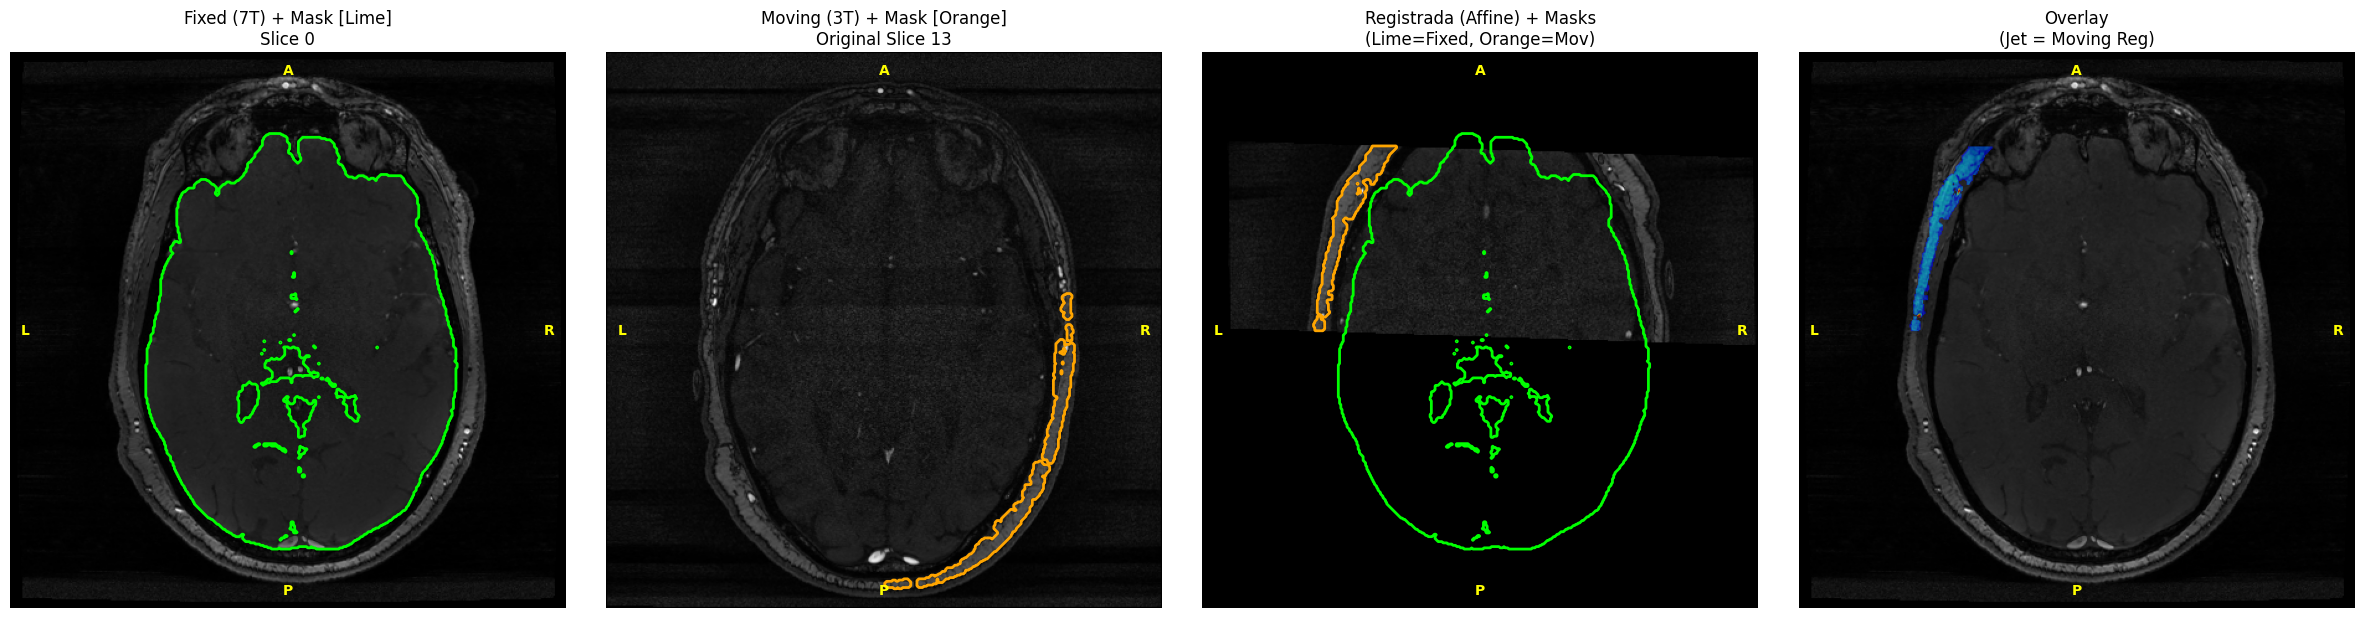

In [2]:
import os
import matplotlib.pyplot as plt
import numpy as np

try:
    import ants
except ImportError as e:
    raise ImportError("ANTsPy not installed. Install with: pip install antspyx") from e

# --- UTILIDADES VISUALES ---
def add_labels_ras(ax):
    """Etiquetas asumiendo orientación RAS"""
    ax.text(0.02, 0.5, "L", transform=ax.transAxes, va="center", ha="left", color="yellow", fontweight="bold")
    ax.text(0.98, 0.5, "R", transform=ax.transAxes, va="center", ha="right", color="yellow", fontweight="bold")
    ax.text(0.5, 0.98, "A", transform=ax.transAxes, va="top", ha="center", color="yellow", fontweight="bold")
    ax.text(0.5, 0.02, "P", transform=ax.transAxes, va="bottom", ha="center", color="yellow", fontweight="bold")

def _to_numpy(img):
    arr = img.numpy()
    if arr.ndim == 4: arr = arr[..., 0]
    return arr

def _load_and_prep(path_or_img, is_mask=False):
    """Carga, maneja 4D y reorienta a RAS."""
    if isinstance(path_or_img, str):
        raw = ants.image_read(path_or_img)
    else:
        raw = path_or_img
        
    # 4D -> 3D (Extraction)
    if raw.dimension == 4:
        img_3d = ants.slice_image(raw, axis=3, idx=0)
    else:
        img_3d = raw
        
    # Reorient to RAS
    img_ras = ants.reorient_image2(img_3d, "RAS")
    return img_ras

def register_ras_slab_fixed(path_fixed_hr, path_moving_lr, path_fixed_mask=None, path_moving_mask=None):
    print("--- V24: Registro Mejorado (N4 Bias Corr + Affine) ---")
    
    # 1. CARGA IMÁGENES
    print("   [1/7] Cargando y Reorientando Imágenes...")
    fixed = _load_and_prep(path_fixed_hr)
    moving = _load_and_prep(path_moving_lr)

    print(f"      Fixed Origin: {fixed.origin}")
    print(f"      Moving Origin: {moving.origin}")

    # 2. PRE-PROCESAMIENTO (N4 Bias Correction)
    # Fundamental para 7T, elimina variaciones de intensidad que confunden el registro
    print("   [2/7] Aplicando N4 Bias Field Correction...")
    fixed = ants.n4_bias_field_correction(fixed)
    moving = ants.n4_bias_field_correction(moving)

    # 3. MÁSCARAS
    print("   [3/7] Preparando Máscaras...")
    
    if path_fixed_mask and os.path.exists(path_fixed_mask):
        print("      -> Usando máscara Fixed externa")
        mask_fixed = _load_and_prep(path_fixed_mask, is_mask=True)
    else:
        print("      -> Generando máscara Fixed (otsu+morphology)")
        # ants.get_mask simple a veces falla en 7T, otsu con cleanup es decente tras N4
        mask_fixed = ants.get_mask(fixed, cleanup=2)

    if path_moving_mask and os.path.exists(path_moving_mask):
        print("      -> Usando máscara Moving externa")
        mask_moving = _load_and_prep(path_moving_mask, is_mask=True)
    else:
        print("      -> Generando máscara Moving (otsu+morphology)")
        mask_moving = ants.get_mask(moving, cleanup=2)

    # 4. INICIALIZACIÓN
    print("   [4/7] Inicializando Transform (Affine)...")
    init_tx = ants.affine_initializer(
        fixed_image=fixed,
        moving_image=moving,
        search_factor=20,
        radian_fraction=0.1,
        use_principal_axis=True,
        local_search_iterations=10,
        mask=mask_fixed
    )

    # 5. REGISTRO (Affine en vez de Rigid para corregir distorsiones geométricas 7T)
    print("   [5/7] Ejecutando Registro (Affine)...")
    tx = ants.registration(
        fixed=fixed,
        moving=moving,
        type_of_transform="Affine",  # Rigid -> Affine mejora scaling/shearing
        initial_transform=init_tx,
        aff_metric="mattes",
        aff_sampling=32,
        reg_iterations=(100, 100, 70, 20), # Más iteraciones
        mask=mask_fixed,
        moving_mask=mask_moving,
        verbose=False
    )

    # 6. APLICAR TRANSFORMACIÓN
    print("   [6/7] Warping (Imagen + Máscara)...")
    
    warped_img = ants.apply_transforms(
        fixed=fixed,
        moving=moving,
        transformlist=tx["fwdtransforms"],
        interpolator="bSpline"
    )
    
    warped_mask = ants.apply_transforms(
        fixed=fixed,
        moving=mask_moving,
        transformlist=tx["fwdtransforms"],
        interpolator="nearestNeighbor"
    )

    # --- VISUALIZACIÓN ---
    print("   [7/7] Visualizando...")
    f_np = _to_numpy(fixed)
    m_np = _to_numpy(moving)
    w_np = _to_numpy(warped_img)
    
    mf_np = _to_numpy(mask_fixed)
    mm_np = _to_numpy(mask_moving)
    wm_np = _to_numpy(warped_mask)

    def normalize(arr):
        return (arr - arr.min()) / (arr.max() - arr.min() + 1e-8)

    f_np = normalize(f_np)
    w_np = normalize(w_np)
    m_np = normalize(m_np)

    # Seleccionar slice con mucho cerebro en la imagen registrada
    slice_sums = np.sum(wm_np, axis=(0,1))
    z_best = np.argmax(slice_sums)
    z_orig = np.argmax(np.sum(mm_np, axis=(0,1)))

    fig, axes = plt.subplots(1, 4, figsize=(24, 6))

    def plot_contour(ax, mask_slice, color):
        if np.sum(mask_slice) > 0:
            ax.contour(mask_slice.T, levels=[0.5], colors=color, linewidths=2, origin='lower')

    # 1. Fixed (7T)
    axes[0].imshow(f_np[:, :, z_best].T, cmap='gray', origin='lower')
    plot_contour(axes[0], mf_np[:, :, z_best], 'lime')
    axes[0].set_title(f"Fixed (7T) + Mask [Lime]\nSlice {z_best}")
    add_labels_ras(axes[0])
    axes[0].axis('off')

    # 2. Moving Original (3T)
    axes[1].imshow(m_np[:, :, z_orig].T, cmap='gray', origin='lower')
    plot_contour(axes[1], mm_np[:, :, z_orig], 'orange')
    axes[1].set_title(f"Moving (3T) + Mask [Orange]\nOriginal Slice {z_orig}")
    add_labels_ras(axes[1])
    axes[1].axis('off')

    # 3. Resultado (Warped)
    axes[2].imshow(w_np[:, :, z_best].T, cmap='gray', origin='lower')
    plot_contour(axes[2], wm_np[:, :, z_best], 'orange') 
    plot_contour(axes[2], mf_np[:, :, z_best], 'lime')  
    axes[2].set_title(f"Registrada (Affine) + Masks\n(Lime=Fixed, Orange=Mov)")
    add_labels_ras(axes[2])
    axes[2].axis('off')

    # 4. Overlay
    alpha_mask = np.where(wm_np[:, :, z_best] > 0.5, 0.6, 0.0)
    axes[3].imshow(f_np[:, :, z_best].T, cmap='gray', origin='lower')
    axes[3].imshow(w_np[:, :, z_best].T, cmap='jet', origin='lower', alpha=alpha_mask.T)
    axes[3].set_title("Overlay\n(Jet = Moving Reg)")
    add_labels_ras(axes[3])
    axes[3].axis('off')

    plt.tight_layout()
    plt.show()

    return tx['fwdtransforms']

# --- EJECUTAR ---
hr_mag = "../data/nifti_patients/001_20240313_7T/Magnitude_NoProto_WIP_fl3d1r3.nii.gz"
lr_mag = "../data/nifti_patients/001_20240313_3T/Magnitude_NoProto_WIP_pc3d1r3.nii.gz"

transforms = register_ras_slab_fixed(hr_mag, lr_mag)